<a href="https://colab.research.google.com/github/HisameOgasahara/deep-learning-diagnostics-and-improvement/blob/main/colab/vit_optimizer_diagnostics/vit_optimizer_dynamics_geometry_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ViT Optimizer Diagnostics Lab

CIFAR-10의 작은 ViT를 같은 초기값에서 **SGD / AdamW / Prodigy / Muon**으로 50 epoch 학습합니다.

실험 흐름:

```text
성능
→ gradient / update dynamics
→ representation geometry
→ class geometry
→ function-space 비교
→ Hessian spectrum
→ mode connectivity / basin
```

기존의 중요한 측정은 유지하고, 더 포괄적인 측정은 상위 진단으로 확장했습니다.

- Hessian top eigenvalue → Lanczos Ritz spectrum
- 단순 weight interpolation → barrier height + midpoint averaging
- gradient norm → gradient cosine / noise / update cosine / displacement까지 확장
- PCA/UMAP 중심 → covariance spectrum / CKA / probe / Neural Collapse / margin / manifold 통계 중심

이번 버전에서는 HP sweep과 scaling sweep은 제외합니다.


## 0. 환경 설정

T4 실행 시간을 고려해 다음을 기본값으로 둡니다.

- epoch: 50
- batch size: 512
- DataLoader workers: 4
- AMP: GPU 사용 시 활성화
- representation checkpoint: 0, 10, 25, 50 epoch
- Hessian: 초기점과 최종점에서만 계산


In [1]:
!pip -q install datasets prodigyopt tensorboard scikit-learn
!git clone -q https://github.com/HisameOgasahara/deep-learning-diagnostics-and-improvement.git /content/dldi || git -C /content/dldi pull -q

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from google.colab import drive
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms

LAB_DIR = "/content/dldi/colab/vit_optimizer_diagnostics"
sys.path.insert(0, LAB_DIR)

from vit_lab_model_optim import SmallViT
from vit_lab_train import train_one_optimizer
from vit_lab_repr import extract_features_and_logits, representation_diagnostics
from vit_lab_landscape import (
    run_function_space_comparison,
    run_hessian_diagnostics,
    run_mode_connectivity,
)


### 실험 설정


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 7

EPOCHS = 50
BATCH_SIZE = 1024
NUM_WORKERS = 4

OPTIMIZER_NAMES = ["sgd", "adamw", "prodigy", "muon"]

DIAG_EPOCHS = [0, 10, 25, 50]
DYNAMICS_EVERY = 5

REP_TRAIN_SAMPLES = 5000
REP_VAL_SAMPLES = 2000
CONNECTIVITY_SAMPLES = 1000

HESSIAN_BATCH_SIZE = 64
LANCZOS_STEPS = 16

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("Native Muon available:", hasattr(torch.optim, "Muon"))


PyTorch: 2.11.0+cu128
Device: cuda
Native Muon available: True


### 결과 저장 위치


In [3]:
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/deep_learning_diagnostics_vit")
CSV_DIR = DRIVE_ROOT / "csv"
FIG_DIR = DRIVE_ROOT / "figures"
TB_DIR = DRIVE_ROOT / "tensorboard"
SUMMARY_DIR = DRIVE_ROOT / "summaries"
LOCAL_CKPT_DIR = Path("/content/vit_optimizer_checkpoints")

for folder in [CSV_DIR, FIG_DIR, TB_DIR, SUMMARY_DIR, LOCAL_CKPT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


Mounted at /content/drive


## 1. 데이터 준비

학습 입력에는 crop / horizontal flip을 적용합니다.

CKA, covariance spectrum, probe처럼 checkpoint 사이 representation을 비교하는 진단에는 **augmentation이 없는 고정 입력**을 사용합니다.


In [4]:
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
)

hf_train = load_dataset("uoft-cs/cifar10", split="train")


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [5]:
class CIFAR10FromHF(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        row = self.dataset[index]
        image = row["img"].convert("RGB")
        label = int(row["label"])
        return self.transform(image), label


train_augmented = CIFAR10FromHF(hf_train, train_transform)
train_fixed = CIFAR10FromHF(hf_train, eval_transform)


In [6]:
permutation = torch.randperm(
    len(train_augmented),
    generator=torch.Generator().manual_seed(SEED),
).tolist()

train_indices = permutation[:40000]
val_indices = permutation[40000:45000]

train_dataset = Subset(train_augmented, train_indices)
train_eval_dataset = Subset(train_fixed, train_indices)
val_dataset = Subset(train_fixed, val_indices)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
)

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs,
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Steps per epoch:", len(train_loader))


Train samples: 40000
Validation samples: 5000
Steps per epoch: 40


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 2. ViT와 공통 초기값

모델 구조:

```text
32x32 image
→ 4x4 patch embedding
→ 6 Transformer blocks
→ LayerNorm
→ classification head
```

네 optimizer는 같은 초기 parameter에서 시작합니다.


In [7]:
torch.manual_seed(SEED)
base_model = SmallViT()

INITIAL_STATE = {
    name: value.detach().cpu().clone()
    for name, value in base_model.state_dict().items()
}

parameter_count = sum(
    parameter.numel()
    for parameter in base_model.parameters()
)

print(f"Parameters: {parameter_count / 1e6:.2f} M")


Parameters: 2.69 M


## 3. 네 optimizer 학습

비교 대상:

- SGD + momentum
- AdamW
- Prodigy
- Muon

학습 중 기록:

- gradient norm
- gradient cosine
- gradient variance / noise ratio
- update norm
- update-to-weight ratio
- update cosine
- 초기값으로부터 parameter displacement


In [8]:
histories = {}
dynamics = {}
gradient_noise = {}

for optimizer_name in OPTIMIZER_NAMES:
    print()
    print("=" * 70)
    print("optimizer:", optimizer_name)
    print("=" * 70)

    history_df, dynamics_df, noise_df = train_one_optimizer(
        run_name=optimizer_name,
        initial_state=INITIAL_STATE,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        epochs=EPOCHS,
        diag_epochs=DIAG_EPOCHS,
        dynamics_every=DYNAMICS_EVERY,
        ckpt_dir=LOCAL_CKPT_DIR,
        csv_dir=CSV_DIR,
        tb_dir=TB_DIR,
        amp_enabled=torch.cuda.is_available(),
    )

    histories[optimizer_name] = history_df
    dynamics[optimizer_name] = dynamics_df
    gradient_noise[optimizer_name] = noise_df



optimizer: sgd


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[sgd    ] epoch 01/50 | train 0.2697 | val 0.2792 | 31.3s
[sgd    ] epoch 02/50 | train 0.3317 | val 0.3162 | 26.5s
[sgd    ] epoch 03/50 | train 0.3824 | val 0.4086 | 27.0s
[sgd    ] epoch 04/50 | train 0.4373 | val 0.4598 | 26.9s
[sgd    ] epoch 05/50 | train 0.4638 | val 0.3884 | 26.3s
[sgd    ] epoch 06/50 | train 0.4836 | val 0.4118 | 26.7s
[sgd    ] epoch 07/50 | train 0.5029 | val 0.4854 | 26.9s
[sgd    ] epoch 08/50 | train 0.5111 | val 0.4738 | 27.0s
[sgd    ] epoch 09/50 | train 0.5242 | val 0.4680 | 27.6s
[sgd    ] epoch 10/50 | train 0.5262 | val 0.5466 | 25.6s
[sgd    ] epoch 11/50 | train 0.5526 | val 0.5118 | 25.9s
[sgd    ] epoch 12/50 | train 0.5479 | val 0.5238 | 26.7s
[sgd    ] epoch 13/50 | train 0.5663 | val 0.5332 | 26.4s
[sgd    ] epoch 14/50 | train 0.5734 | val 0.5358 | 26.5s
[sgd    ] epoch 15/50 | train 0.5769 | val 0.5592 | 24.8s
[sgd    ] epoch 16/50 | train 0.5825 | val 0.5040 | 27.2s
[sgd    ] epoch 17/50 | train 0.5811 | val 0.5500 | 27.4s
[sgd    ] epoc

### 최종 성능 비교


In [9]:
history = pd.concat(histories.values(), ignore_index=True)
history.to_csv(CSV_DIR / "all_history.csv", index=False)

final_table = (
    history
    .groupby("run", as_index=False)
    .tail(1)[
        [
            "run",
            "train_accuracy",
            "val_accuracy",
            "val_loss",
            "seconds",
        ]
    ]
    .sort_values("val_accuracy", ascending=False)
)

final_table


,run,train_accuracy,val_accuracy,val_loss,seconds
199,muon,0.923375,0.7686,0.800213,28.299550
99,adamw,0.831300,0.7594,0.731909,26.717071
149,prodigy,0.787550,0.7464,0.745705,27.657865
49,sgd,0.704925,0.6538,0.960434,27.476155


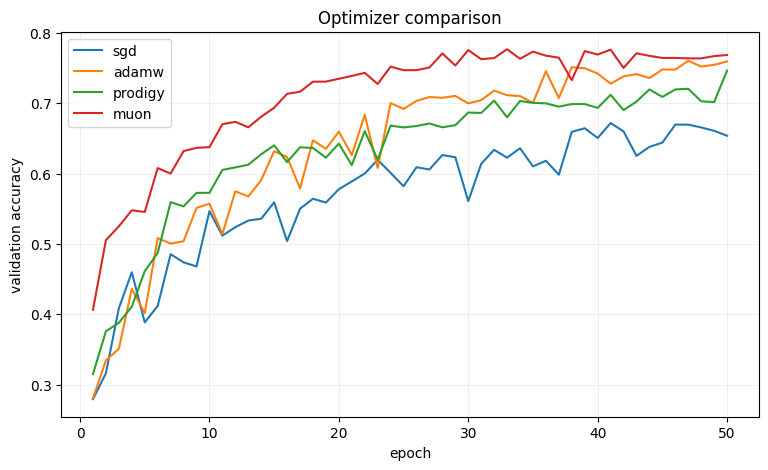

In [10]:
plt.figure(figsize=(9, 5))

for optimizer_name, frame in histories.items():
    plt.plot(
        frame["epoch"],
        frame["val_accuracy"],
        label=optimizer_name,
    )

plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("Optimizer comparison")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 4. Gradient / update dynamics

같은 대표 parameter에서 optimizer가 gradient를 실제 update로 어떻게 바꾸는지 비교합니다.

핵심 질문:

1. gradient 방향은 얼마나 일관적인가?
2. minibatch noise는 얼마나 큰가?
3. 실제 update 방향은 gradient와 어떻게 달라지는가?
4. 각 layer는 초기값에서 얼마나 멀리 이동했는가?


In [11]:
dynamics_all = pd.concat(dynamics.values(), ignore_index=True)
noise_all = pd.concat(gradient_noise.values(), ignore_index=True)

display(dynamics_all.head())
display(noise_all.head())


,run,epoch,step,parameter,grad_norm,grad_cosine_prev,update_norm,update_to_weight,update_cosine_prev,parameter_displacement
0,sgd,1,0,patch_embed.proj.weight,0.345809,NaN,0.010375,0.001285,NaN,0.010375
1,sgd,1,0,blocks.0.attn.in_proj_weight,0.392048,NaN,0.011764,0.000694,NaN,0.011764
2,sgd,1,0,blocks.3.mlp.fc1.weight,0.361538,NaN,0.010847,0.001415,NaN,0.010847
3,sgd,1,0,head.weight,1.324389,NaN,0.039733,0.045494,NaN,0.039733
4,sgd,1,5,patch_embed.proj.weight,0.220297,0.078502,0.016429,0.002036,0.584126,0.082455


,run,epoch,parameter,grad_mean_norm,grad_variance_trace,gradient_noise_ratio
0,sgd,1,patch_embed.proj.weight,0.214962,0.236055,5.108441
1,sgd,1,blocks.0.attn.in_proj_weight,0.255682,0.343391,5.252778
2,sgd,1,blocks.3.mlp.fc1.weight,0.091262,0.068310,8.201615
3,sgd,1,head.weight,0.323551,0.890523,8.506655
4,sgd,2,patch_embed.proj.weight,0.144171,0.405291,19.498934


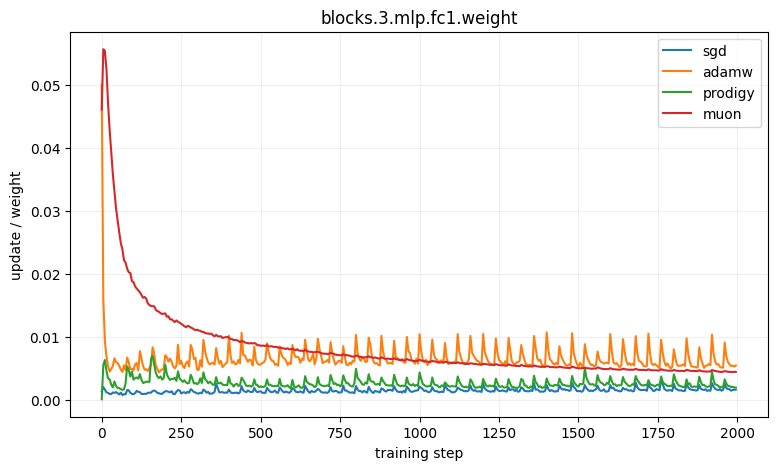

In [12]:
tracked_parameter = "blocks.3.mlp.fc1.weight"

plt.figure(figsize=(9, 5))

for optimizer_name in OPTIMIZER_NAMES:
    frame = dynamics_all[
        (dynamics_all["run"] == optimizer_name)
        & (dynamics_all["parameter"] == tracked_parameter)
    ]

    plt.plot(
        frame["step"],
        frame["update_to_weight"],
        label=optimizer_name,
    )

plt.xlabel("training step")
plt.ylabel("update / weight")
plt.title(tracked_parameter)
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 5. Representation geometry

진단 checkpoint 0 / 10 / 25 / 50에서 다음을 계산합니다.

각 layer:

- covariance eigenspectrum
- effective rank
- CKA to initialization
- linear probe accuracy

penultimate representation:

- Neural Collapse NC1 / NC2 / NC3
- margin distribution
- kNN neighborhood purity
- class radius
- class participation dimension
- class-center correlation


In [13]:
def make_fixed_loader(dataset, sample_count):
    count = min(sample_count, len(dataset))

    subset = Subset(
        dataset,
        list(range(count)),
    )

    return DataLoader(
        subset,
        batch_size=512,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=NUM_WORKERS > 0,
    )


rep_train_loader = make_fixed_loader(
    train_eval_dataset,
    REP_TRAIN_SAMPLES,
)

rep_val_loader = make_fixed_loader(
    val_dataset,
    REP_VAL_SAMPLES,
)


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [14]:
initial_model = SmallViT().to(DEVICE)
initial_model.load_state_dict(INITIAL_STATE)

init_train_features, _, init_train_labels = extract_features_and_logits(
    initial_model,
    rep_train_loader,
    DEVICE,
)

init_val_features, init_val_logits, init_val_labels = extract_features_and_logits(
    initial_model,
    rep_val_loader,
    DEVICE,
)

del initial_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [15]:
representation_df, covariance_spectrum_df, class_geometry_df = (
    representation_diagnostics(
        optimizer_names=OPTIMIZER_NAMES,
        diag_epochs=DIAG_EPOCHS,
        initial_state=INITIAL_STATE,
        init_train_features=init_train_features,
        init_train_labels=init_train_labels,
        init_val_features=init_val_features,
        init_val_logits=init_val_logits,
        init_val_labels=init_val_labels,
        rep_train_loader=rep_train_loader,
        rep_val_loader=rep_val_loader,
        ckpt_dir=LOCAL_CKPT_DIR,
        csv_dir=CSV_DIR,
        device=DEVICE,
    )
)

display(representation_df.head(20))


,run,epoch,layer,effective_rank,cka_to_init,linear_probe_accuracy
0,sgd,0,patch,1.883541,1.000000,0.2675
1,sgd,0,block2,4.429436,1.000000,0.3905
2,sgd,0,block4,5.338078,1.000000,0.3850
3,sgd,0,block6,5.287387,1.000000,0.3830
4,sgd,0,penultimate,6.346611,1.000000,0.3780
5,sgd,10,patch,3.276097,0.873636,0.2640
6,sgd,10,block2,15.352878,0.404196,0.4720
7,sgd,10,block4,17.726949,0.383134,0.5170
8,sgd,10,block6,17.951407,0.386327,0.5320
9,sgd,10,penultimate,18.812994,0.399198,0.5285


### Class geometry 비교


In [16]:
class_geometry_df.sort_values(
    ["epoch", "run"],
)[
    [
        "run",
        "epoch",
        "nc1_within_between",
        "nc2_etf_error",
        "nc3_classifier_alignment",
        "margin_mean",
        "margin_p10",
        "knn_purity",
        "mean_class_radius",
        "mean_class_participation_dim",
        "class_center_abs_correlation",
    ]
]


,run,epoch,nc1_within_between,nc2_etf_error,nc3_classifier_alignment,margin_mean,margin_p10,knn_purity,mean_class_radius,mean_class_participation_dim,class_center_abs_correlation
4,adamw,0,9.432422,0.594176,-0.033969,-0.450224,-0.829392,0.18665,11.336931,3.096983,0.527703
12,muon,0,9.432422,0.594176,-0.033969,-0.450224,-0.829392,0.18665,11.336931,3.096983,0.527703
8,prodigy,0,9.432422,0.594176,-0.033969,-0.450224,-0.829392,0.18665,11.336931,3.096983,0.527703
0,sgd,0,9.432422,0.594176,-0.033969,-0.450224,-0.829392,0.18665,11.336931,3.096983,0.527703
5,adamw,10,1.579806,0.478022,0.902158,0.124723,-2.073061,0.44270,8.887819,8.138886,0.444401
13,muon,10,1.421527,0.429611,0.916462,0.775615,-2.075284,0.55060,10.467301,12.096792,0.402801
9,prodigy,10,1.786417,0.456488,0.895216,0.234761,-2.129869,0.46365,10.181515,10.615217,0.423900
1,sgd,10,3.023298,0.463731,0.837214,0.144554,-2.085249,0.37785,9.376994,11.585870,0.408999
6,adamw,25,1.344805,0.373144,0.926357,1.189317,-1.993376,0.58380,9.515363,10.831969,0.337892
14,muon,25,1.239325,0.333938,0.948702,1.829304,-1.778413,0.67660,10.528507,16.093473,0.305030


## 6. Function-space 비교

Parameter와 representation이 달라도 최종 함수가 비슷할 수 있습니다.

최종 checkpoint에서 다음을 비교합니다.

- ECE
- pairwise logit MSE
- prediction disagreement


In [17]:
function_df, function_pair_df = run_function_space_comparison(
    optimizer_names=OPTIMIZER_NAMES,
    final_epoch=EPOCHS,
    loader=rep_val_loader,
    ckpt_dir=LOCAL_CKPT_DIR,
    csv_dir=CSV_DIR,
    device=DEVICE,
)

display(function_df)
display(function_pair_df)


,run,ece
0,sgd,0.063701
1,adamw,0.068983
2,prodigy,0.039308
3,muon,0.108222


,run_a,run_b,logit_mse,prediction_disagreement
0,sgd,adamw,3.444596,0.3255
1,sgd,prodigy,2.332551,0.3130
2,sgd,muon,4.910142,0.3340
3,adamw,prodigy,2.206024,0.2300
4,adamw,muon,3.595977,0.2575
5,prodigy,muon,3.427695,0.2500


## 7. Hessian Ritz spectrum

기존의 Hessian 최대 고유값 하나만 보는 진단을 Lanczos Ritz spectrum으로 확장합니다.

확인할 것:

- 최대 Ritz value
- 최소 Ritz value
- spectral spread
- gradient와 최대 곡률 방향의 alignment
- gradient와 최소 곡률 방향의 alignment

음의 Ritz value가 잡히면 조사한 부분공간 안에 음의 곡률 방향이 존재한다는 신호로 해석할 수 있습니다.


In [18]:
hessian_loader = DataLoader(
    Subset(
        val_dataset,
        list(range(HESSIAN_BATCH_SIZE)),
    ),
    batch_size=HESSIAN_BATCH_SIZE,
    shuffle=False,
)

hessian_batch = next(iter(hessian_loader))


In [20]:
# Hessian-vector product는 2차 미분이 필요하므로
# efficient/fused SDPA 대신 math backend를 사용합니다.

torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)

if hasattr(torch.backends.cuda, "enable_cudnn_sdp"):
    torch.backends.cuda.enable_cudnn_sdp(False)

print("Hessian attention backend: math SDPA")

Hessian attention backend: math SDPA


In [21]:
hessian_df, hessian_summary = run_hessian_diagnostics(
    optimizer_names=OPTIMIZER_NAMES,
    final_epoch=EPOCHS,
    initial_state=INITIAL_STATE,
    hessian_batch=hessian_batch,
    ckpt_dir=LOCAL_CKPT_DIR,
    csv_dir=CSV_DIR,
    device=DEVICE,
    steps=LANCZOS_STEPS,
)

hessian_summary


Hessian Lanczos: init
Hessian Lanczos: sgd
Hessian Lanczos: adamw
Hessian Lanczos: prodigy
Hessian Lanczos: muon


,run,min_ritz,max_ritz,grad_align_top,grad_align_min,spectral_spread
0,adamw,-35.951460,124.967759,0.194640,0.099830,160.919219
1,init,-51.493845,68.401159,0.042331,0.037625,119.895005
2,muon,-310.710112,304.045249,0.444620,0.367372,614.755360
3,prodigy,-105.268509,178.657309,0.022339,0.074908,283.925818
4,sgd,-25.892476,106.276219,0.421578,0.090850,132.168695


## 8. Mode connectivity / basin

두 optimizer의 최종 checkpoint 사이를 alpha = 0에서 1까지 직선으로 연결합니다.

각 alpha에서 validation loss를 측정하고 다음을 정량화합니다.

- barrier height
- midpoint loss
- midpoint accuracy

단순히 interpolation 그림만 보는 것보다 두 해 사이의 저손실 연결성을 비교하기 쉽습니다.


In [22]:
connectivity_loader = make_fixed_loader(
    val_dataset,
    CONNECTIVITY_SAMPLES,
)

connectivity_df, barrier_df = run_mode_connectivity(
    optimizer_names=OPTIMIZER_NAMES,
    final_epoch=EPOCHS,
    loader=connectivity_loader,
    ckpt_dir=LOCAL_CKPT_DIR,
    csv_dir=CSV_DIR,
    device=DEVICE,
    max_samples=CONNECTIVITY_SAMPLES,
)

barrier_df


Mode connectivity: sgd <-> adamw


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Mode connectivity: sgd <-> prodigy
Mode connectivity: sgd <-> muon
Mode connectivity: adamw <-> prodigy
Mode connectivity: adamw <-> muon
Mode connectivity: prodigy <-> muon


,run_a,run_b,barrier_height,midpoint_loss,midpoint_accuracy
0,sgd,adamw,0.590119,1.451821,0.476
1,sgd,prodigy,0.069130,1.030832,0.643
2,sgd,muon,0.689958,1.135673,0.602
3,adamw,prodigy,0.660039,1.290724,0.560
4,adamw,muon,1.359585,1.291857,0.606
5,prodigy,muon,1.234331,1.028798,0.667


## 9. 최종 해석 순서

결과는 다음 순서로 읽습니다.

```text
성능이 실제로 다른가?
↓
gradient와 update가 어떻게 달랐는가?
↓
어느 layer의 representation이 달라졌는가?
↓
class geometry와 margin이 어떻게 달라졌는가?
↓
실제 출력 함수도 달라졌는가?
↓
최종점 주변의 curvature는 어떻게 다른가?
↓
서로 다른 optimizer의 해 사이에 loss barrier가 있는가?
```

이 구조를 사용하면 단순히 "어느 optimizer가 점수가 높았다"에서 끝나지 않고, 학습동역학 → 표현 → 함수 → loss landscape로 원인을 단계적으로 좁힐 수 있습니다.


In [23]:
summary = {
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "optimizers": OPTIMIZER_NAMES,
    "final_metrics": final_table.to_dict(orient="records"),
    "hessian": hessian_summary.to_dict(orient="records"),
    "mode_connectivity": barrier_df.to_dict(orient="records"),
}

with open(
    SUMMARY_DIR / "experiment_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Saved to:", DRIVE_ROOT)


Saved to: /content/drive/MyDrive/deep_learning_diagnostics_vit
